# Testing a causal discovery and causal inference pipeline on synthetic data

## Notebook outline

The notebook runs through the following:

1. Create synthetic data with known causal relationships
2. Identify a DAG using Peter-Clarke algorithm
3. Formalise the output of the DAG
4. Measure average treatment effects (ATE) with Linear Double Machine Learning
5. Run refutation tests on the average treatment effect
6. Measure conditional average treatment effects with Causal Forest


## Rules for synthetic data

Synthetic data based on:

POPULATION:

* Patients are aged 60-95, uniformly distrIbuted
* Ethnicity is 70% white, 20% asian, 10% black
* Patients are split 50:50 male:female

MORTALITY:

* Baseline mortality is 10%
* Mortality increases by 1 percentage point every year above age 60
* Mortality increases 5% points for asian patients and 10% for black patients
* Mortality increases 10% points for males

THROMBOLYSIS USE:

* Baseline thrombolysis treatment is 20%
* Thrombolysis rate is reduced 5% for asian patients and 10% for black patients
* Thrombolysis rate is halved if aged more than 80

THROMBOLYSIS EFFICACY

* The baseline effect of use of thrombolysis is to halve mortality
* Thrombolysis is half as effective in asian and black people
* Thrombolysis is half as effective if aged 80%

## Causal forest outline

![](./causal_forest.png)

In [1]:
# Import general modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.preprocessing import LabelEncoder

# Import causal-learn modules
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

# Import Causal Forest modules
from dowhy import CausalModel
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier



## Create synthetic dataset

In [2]:
# ──── 1. Create Synthetic Data ────

np.random.seed(42)
N = 25_000

# --- Demographics ---
age = np.random.randint(60, 96, size=N)  # 60–95 inclusive
ethnicity = np.random.choice(['white', 'asian', 'black'], size=N, p=[0.70, 0.20, 0.10])
male = np.random.randint(0, 2, size=N)  # 0=female, 1=male

# --- Thrombolysis probability ---
thrombolysis_prob = np.full(N, 0.20)
thrombolysis_prob[ethnicity == 'asian'] -= 0.05
thrombolysis_prob[ethnicity == 'black'] -= 0.10
thrombolysis_prob[age > 80] /= 2
thrombolysis_prob = np.clip(thrombolysis_prob, 0, 1)

thrombolysis = np.random.binomial(1, thrombolysis_prob)

# --- Mortality probability ---
mortality_prob = np.full(N, 0.10)
mortality_prob += (age - 60) * 0.01                          # +1pp per year above 60
mortality_prob[ethnicity == 'asian'] += 0.05
mortality_prob[ethnicity == 'black'] += 0.10
mortality_prob[male == 1] += 0.10

# --- Thrombolysis effect on mortality ---
# Baseline: halves mortality (multiplier 0.5 → reduction of 0.5)
# Each "half as effective" halves the reduction: multiplier 0.75 per condition
reduced_effectiveness = (ethnicity == 'asian') | (ethnicity == 'black')
age_over_80_treated   = (thrombolysis == 1) & (age > 80)
ethnicity_reduced     = (thrombolysis == 1) & reduced_effectiveness
both                  = age_over_80_treated & ethnicity_reduced

thrombolysis_effect = np.where(thrombolysis == 0, 1.0,
    np.where(both, 0.875,
        np.where(age_over_80_treated | ethnicity_reduced, 0.75, 0.5)
    )
)

mortality_prob *= thrombolysis_effect
mortality_prob = np.clip(mortality_prob, 0, 1)

# --- Outcome ---
died = np.random.binomial(1, mortality_prob)

# --- DataFrame ---
df = pd.DataFrame({
    'patient_id':       np.arange(1, N + 1),
    'age':              age,
    'ethnicity':        ethnicity,
    'male':             male,
    'thrombolysis':     thrombolysis,
    'mortality_prob':   np.round(mortality_prob, 4),
    'died':             died
})

# --- Save to CSV ---
df.to_csv('synthetic_stroke_data_1.csv', index=False)

### Compute true CATE for each patient

CATE = Conditional average treatment effect (the effect for each patient, depending on patient characteristics)

In [3]:
# ── 2. Compute TRUE CATE from data-generating process ────────────────────────

# Mortality probability WITHOUT treatment
mortality_base = np.full(len(df), 0.10)
mortality_base += (df['age'].values - 60) * 0.01
mortality_base[df['ethnicity'] == 'asian'] += 0.05
mortality_base[df['ethnicity'] == 'black'] += 0.10
mortality_base[df['male'] == 1] += 0.10
mortality_base = np.clip(mortality_base, 0, 1)

# Mortality probability WITH treatment (using the effect multipliers)
reduced_effectiveness = (df['ethnicity'] == 'asian') | (df['ethnicity'] == 'black')
age_over_80 = df['age'].values > 80
both = age_over_80 & reduced_effectiveness.values

treatment_multiplier = np.where(both, 0.875,
    np.where(age_over_80 | reduced_effectiveness.values, 0.75, 0.5))

mortality_treated = np.clip(mortality_base * treatment_multiplier, 0, 1)

# True CATE = E[Y(1)] - E[Y(0)] — negative means treatment reduces mortality
true_cate = mortality_treated - mortality_base
df['true_cate'] = true_cate

## Identify causal relationships using causallearn.search.ConstraintBased.PC

The `causallearn.search.ConstraintBased.PC` function is an implementation of the Peter-Clark (PC) algorithm in the `causal-learn` Python library. As a constraint-based causal discovery method, the PC algorithm uses conditional independence tests on observational data to identify causal relationships, returning a Directed Acyclic Graph (DAG) or Partially Directed Acyclic Graph (CPDAG). [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

The algorithm systematically prunes a fully connected network into a sparse graph based on statistical evidence, assuming there are no unmeasured (latent) confounders. [lmyint.github](https://lmyint.github.io/causal_spring_2020/causal-discovery.html)

### 1. Skeleton Discovery (Adjacency Search)
The PC algorithm begins with a fully connected graph containing all observed variables. It iteratively removes edges by testing for conditional independence. First, it tests all pairs of variables for marginal (unconditional) independence, removing edges where no association is found. It then tests remaining adjacent variables for conditional independence given subsets of size 1, then size 2, increasing the subset size systematically. If $X$ and $Y$ are found to be conditionally independent given a subset $Z$, the edge between them is deleted, and $Z$ is recorded as the "separation set" (sepset) for that pair. [jmlr](https://jmlr.org/papers/volume15/colombo14a/colombo14a.pdf)

### 2. Collider Orientation (v-structures)
Once the skeleton is finalized, the algorithm looks for unshielded triples—patterns where variable $X$ is connected to $Y$, and $Y$ is connected to $Z$, but $X$ and $Z$ are not connected. For each unshielded triple $X - Y - Z$, it checks the sepset recorded when the edge between $X$ and $Z$ was deleted. If $Y$ is *not* in that sepset, the algorithm orients the edges toward $Y$ to form a collider (v-structure): $X \rightarrow Y \leftarrow Z$. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

### 3. Edge Orientation Rules
After identifying all colliders, the algorithm applies a set of logical rules (Meek rules) to orient as many remaining undirected edges as possible without creating new colliders or cycles. For example, if it finds $X \rightarrow Y - Z$ and orienting $Y \leftarrow Z$ would create a new collider that wasn't identified in step 2, it logically forces the orientation $Y \rightarrow Z$. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

### Python Implementation and Parameters
In `causal-learn`, the `pc()` function is called with the dataset (a NumPy array) and allows for several key configurations: [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `alpha`: The significance level for the conditional independence tests (default 0.05). [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `indep_test`: The statistical test used, such as Fisher's Z (`fisherz`) for linear continuous data, Chi-squared for discrete data, or Kernel-based (`kci`) for non-linear continuous data. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `uc_rule` and `uc_priority`: Define how the algorithm handles conflicting unshielded colliders, offering options like maxP (orienting based on additional CI tests) to improve robustness. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)
- `mvpc`: Allows the algorithm to handle missing values natively. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

The function returns a `CausalGraph` object (`cg`), where `cg.G.graph` contains the final adjacency matrix representing the discovered causal relationships. [causal-learn.readthedocs](https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/PC.html)

  0%|          | 0/5 [00:00<?, ?it/s]

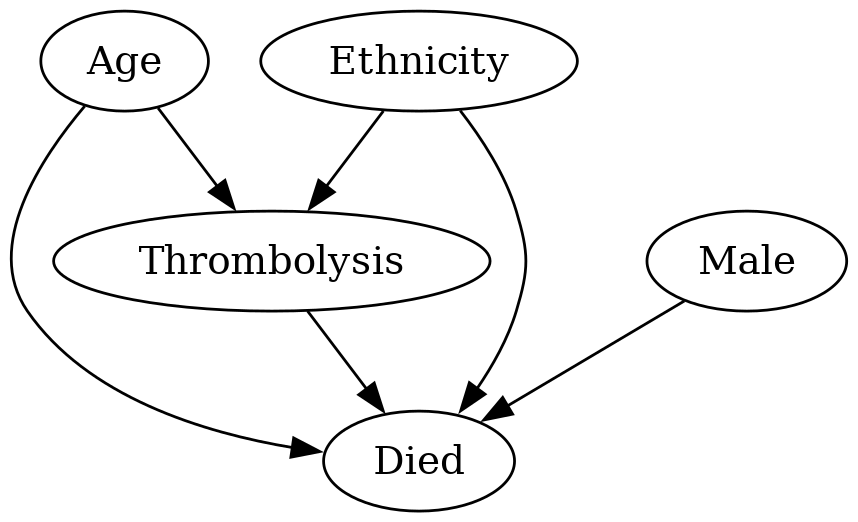

In [4]:
# --- Preprocessing ---
# 1. Map ethnicity to numeric values for the algorithm
ethnicity_map = {'white': 0, 'asian': 1, 'black': 2}
df['ethnicity_idx'] = df['ethnicity'].map(ethnicity_map)

# 2. Select only the features relevant to the causal structure
feature_cols = ['age', 'ethnicity_idx', 'male', 'thrombolysis', 'died']
data_for_pc = df[feature_cols].to_numpy()

# Define the labels in the same order as feature_cols
node_names = ['Age', 'Ethnicity', 'Male', 'Thrombolysis', 'Died']

# Run PC with names, alpha=0.05 is the significance level for independence tests
cg = pc(data_for_pc, alpha=0.05, node_names=node_names)

# --- Visualization using Graphviz ---
pyd = GraphUtils.to_pydot(cg.G)
pyd.write_png('stroke_causal_dag.png')

# To display directly in a Jupyter Notebook:
from IPython.display import Image
Image('stroke_causal_dag.png')

## Define causal model (Formalise the output of the DAG)

This Python code is using the `dowhy` library (specifically its `CausalModel` class) to define and analyze a causal inference problem. It represents the first two steps of the standard DoWhy workflow: **Modeling** and **Identification**. [datacamp](https://www.datacamp.com/tutorial/intro-to-causal-ai-using-the-dowhy-library-in-python)

Here is what is happening step-by-step:

### 1. Defining the Causal Model
The `CausalModel` block creates an explicit map of the assumptions you are making about your data:
- `data=df`: You are passing in a pandas DataFrame (`df`) containing your observational data.
- `treatment='thrombolysis'`: You are specifying that "thrombolysis" is the intervention or cause you want to study.
- `outcome='died'`: You are specifying that "died" (mortality) is the effect you want to measure.
- `common_causes=['age', 'ethnicity_idx', 'male']`: These are the confounding variables (variables that affect *both* whether a patient receives thrombolysis and their risk of dying). You are telling the model it must adjust for these to prevent biased results. [perplexity](https://www.perplexity.ai/search/e57c770c-88dd-4e89-87ac-3fbbbaac2dd6)
- `effect_modifiers=['age', 'ethnicity_idx']`: These are variables that don't necessarily cause the treatment, but they change *how effective* the treatment is. By specifying these, you are preparing the model to calculate Conditional Average Treatment Effects (CATE), allowing you to see how thrombolysis works differently for different age groups or ethnicities. [perplexity](https://www.perplexity.ai/search/e1b532f7-38b1-406e-95f0-f02e1117bea1)

### 2. Identifying the Causal Effect (`identify_effect`)
The line `identified_estimand = model.identify_effect(...)` asks the DoWhy library to look at the causal model you just defined and determine the mathematical recipe (the "estimand") required to isolate the true causal effect from the data. [causalwizard](https://causalwizard.app/inference/article/identification)
- It uses the rules of causal graphs (like Pearl's *do*-calculus or backdoor criteria) to translate the causal question ("What happens if we *force* thrombolysis?") into a statistical formula that can be calculated using purely observational data. [pywhy](https://www.pywhy.org/dowhy/v0.14/user_guide/causal_tasks/estimating_causal_effects/identifying_causal_effect/index.html)
- The argument `proceed_when_unidentifiable=True` tells the algorithm to push forward and return an estimand even if it detects that some assumptions are violated or unmeasured confounders might prevent a perfect mathematical identification. 


In [5]:
model = CausalModel(
    data=df,
    treatment='thrombolysis',
    outcome='died',
    common_causes=['age', 'ethnicity_idx', 'male'],
    effect_modifiers=['age', 'ethnicity_idx']
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("Identified Estimand:\n", identified_estimand)

# Output is given as:

# Estimand 1: backdoor - uses backdoor method defined by Pearl
# Estimand 2: instrument variable (IV)
# Estimand 3: frontdoor - uses frontdoor method defined by Pearl
# Estimand 4: general adjustment. This is a generalized version of covariate adjustment that often mirrors the backdoor set in standard causal DAGs

# "No such variable(s) found!" mean that the method did not find a valid set of variables to adjust for using that method.

# 'U' is unmeasured confounders

Identified Estimand:
 Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                       
───────────────(E[died|age,male,ethnicity_idx])
d[thrombolysis]                                
Estimand assumption 1, Unconfoundedness: If U→{thrombolysis} and U→died then P(died|thrombolysis,age,male,ethnicity_idx,U) = P(died|thrombolysis,age,male,ethnicity_idx)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                       
───────────────(E[died|age,male,ethnicity_idx])
d[thrombolysis]                                
Estimand assumption 1, Unconfoundedness: If U→{thrombolysis} and U→died then P(died|thrombolysis,age,male,ethnicity_idx,U) = P(died|thrombolysis,age,male,ethnicity_idx)



## Measure average treatment effects

This section uses the `dowhy` library paired with Microsoft's `econml` library to estimate the ATE using only the observable data. [pywhy](https://www.pywhy.org/dowhy/v0.10.1/example_notebooks/dowhy-conditional-treatment-effects.html)

It uses a specific technique called **Double Machine Learning (DML)** (`LinearDML`): [pywhy](https://www.pywhy.org/dowhy/v0.10.1/example_notebooks/dowhy-conditional-treatment-effects.html)
- **`model_y`**: A Random Forest Classifier is used to predict the outcome (mortality) based on patient characteristics.
- **`model_t`**: A second Random Forest Classifier is used to predict who gets the treatment (thrombolysis) based on patient characteristics (this is the propensity score). [perplexity](https://www.perplexity.ai/search/521b3429-2f7a-4d8e-865f-c88473867261)
- The `LinearDML` algorithm takes the residual errors from both of these Random Forest models and mathematically combines them to isolate the pure causal effect of the treatment on the outcome, stripping away the confounding variables (like age and ethnicity).

In [6]:
# Print actual treatment effect 
# Since our true CATE is already computed in the DataFrame, we can calculate the average true effect across the entire dataset:
true_ate = df['true_cate'].mean()
print("True ATE:", true_ate)

# Calculate and show calulated ATE using the backdoor method with EconML's LinearDML

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": RandomForestClassifier(n_estimators=200, random_state=42),
            "model_t": RandomForestClassifier(n_estimators=200, random_state=42),
            "discrete_treatment": True,
            "discrete_outcome": True,
            "random_state": 42,
        },
        "fit_params": {}
    }
)

print("Estimated ATE:", estimate.value)


True ATE: -0.10428395
Estimated ATE: [-0.10916668]


## Refutation tests

This code executes two "refutation" tests using the DoWhy library. In causal inference, you can never mathematically prove that your causal assumptions (like "no unobserved confounding") are completely true. Instead, DoWhy uses refutation tests to "stress test" your estimate by deliberately breaking the data or adding simulated noise to see if your model behaves as expected. [causalwizard](https://causalwizard.app/inference/article/placebo-treatment)

### Test 1: Placebo Treatment Refuter
This block uses the `placebo_treatment_refuter`. [pywhy](https://www.pywhy.org/dowhy/v0.14/user_guide/refuting_causal_estimates/refuting_effect_estimates/placebo_treatment.html)
- **What it does:** It takes your original dataset and replaces the real treatment variable (`thrombolysis`) with an independent random variable (a "placebo"), such as by randomly shuffling the treatment assignments among your patients. It then recalculates the causal effect. [pywhy](https://www.pywhy.org/dowhy/v0.14/user_guide/refuting_causal_estimates/refuting_effect_estimates/placebo_treatment.html)
- **Why it matters:** Because the treatment is now entirely random noise, it cannot possibly cause the outcome (`died`). Therefore, the newly estimated causal effect should be exactly or very close to zero. [pywhy](https://www.pywhy.org/dowhy/v0.8/user_guide/effect_inference/refute.html)
- **How to interpret it:** If the refutation result for the placebo test returns an effect close to zero and a high p-value (e.g., > 0.05), your estimator passes the test. If it returns a large effect or a low p-value, it indicates that your model is incorrectly finding a causal effect where none exists, meaning your original estimation procedure is flawed or biased. [pywhy](https://www.pywhy.org/dowhy/main/user_guide/refuting_causal_estimates/refuting_effect_estimates/index.html)

### Test 2: Unobserved Confounder Refuter
This block uses the `add_unobserved_common_cause` refuter, which performs a sensitivity analysis. [causal-inference-zerotoall.github](https://causal-inference-zerotoall.github.io/dowhy_zh/dowhy.causal_refuters.html)
- **What it does:** It simulates a new, unmeasured "ghost" variable (a confounder) and injects it into your dataset, mathematically forcing it to correlate with both the treatment and the outcome. [causal-inference-zerotoall.github](https://causal-inference-zerotoall.github.io/dowhy_zh/dowhy.causal_refuters.html)
- **The Parameters:** 
  - `effect_strength_on_treatment=0.01`: Simulates how strongly the hidden confounder influences the treatment. In a binary scenario, this means the confounder randomly flips the treatment value 1% of the time. [causal-inference-zerotoall.github](https://causal-inference-zerotoall.github.io/dowhy_zh/dowhy.causal_refuters.html)
  - `effect_strength_on_outcome=0.02`: Simulates how strongly the confounder affects the outcome, such as increasing the probability of mortality by 2% per unit of the confounder. [causal-inference-zerotoall.github](https://causal-inference-zerotoall.github.io/dowhy_zh/dowhy.causal_refuters.html)
- **Why it matters:** It tests how robust your original causal estimate is to violations of the Unconfoundedness assumption. In observational medical data, there are almost always unmeasured variables (like a patient's exact frailty). [pywhy](https://www.pywhy.org/dowhy/main/user_guide/refuting_causal_estimates/refuting_effect_estimates/index.html)
- **How to interpret it:** If adding this simulated confounder drastically changes your estimated causal effect or flips its sign (e.g., from a positive benefit to a negative harm), your original estimate is highly sensitive and fragile. If the new estimate remains relatively stable and close to your original estimate, you can be more confident that a minor unmeasured confounder wouldn't invalidate your findings. [pywhy](https://www.pywhy.org/dowhy/v0.8/user_guide/effect_inference/refute.html)

In [7]:
# Test 1: Placebo Treatment (Replace treatment with random noise)
res_placebo = model.refute_estimate(
    identified_estimand, estimate, method_name="placebo_treatment_refuter",
    method_params={
        "init_params": {
            "model_y": RandomForestRegressor(n_estimators=200, random_state=42),
            "model_t": RandomForestClassifier(n_estimators=200, random_state=42),
            "discrete_treatment": True,
            "discrete_outcome": False, # Treat as continuous
            "random_state": 42,
        },
        "fit_params": {}
    }
)
print(f"Placebo Test: {res_placebo.refutation_result}")

Placebo Test: {'p_value': np.float64(0.8), 'is_statistically_significant': np.False_}


In [8]:
# Test 2: Irrelevant Additional Confounder

estimate_for_refuter = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": RandomForestRegressor(n_estimators=200, random_state=42),
            "model_t": RandomForestClassifier(n_estimators=200, random_state=42),
            "discrete_treatment": True,
            "discrete_outcome": False,
            "random_state": 42,
        },
        "fit_params": {}
    }
)

res_unobserved = model.refute_estimate(
    identified_estimand,
    estimate_for_refuter,
    method_name="add_unobserved_common_cause",
    effect_strength_on_treatment=0.01,
    effect_strength_on_outcome=0.02
)

# DoWhy summary (more informative than .refutation_result for this refuter)
print(res_unobserved)

# Optional: explicit numeric comparison
old_eff = getattr(res_unobserved, "estimated_effect", None)
new_eff = getattr(res_unobserved, "new_effect", None)

print(f"\nEstimated effect (original): {old_eff}")
print(f"Estimated effect (with simulated unobserved confounder): {new_eff}")

if old_eff is not None and new_eff is not None:
    abs_shift = abs(new_eff - old_eff)
    rel_shift = abs_shift / (abs(old_eff) + 1e-12)
    print(f"Absolute shift: {abs_shift:.6f}")
    print(f"Relative shift: {rel_shift:.2%}")

Refute: Add an Unobserved Common Cause
Estimated effect:-0.11043426963937658
New effect:-0.10548940187006461


Estimated effect (original): -0.11043426963937658
Estimated effect (with simulated unobserved confounder): -0.10548940187006461
Absolute shift: 0.004945
Relative shift: 4.48%


## Measure conditional average treatment effects with Causal Forest

Both `LinearDML` and `CausalForestDML` share the same **Double Machine Learning (DML) first stage** — they both residualise the outcome and treatment by fitting nuisance models for `E[Y|X,W]` and `E[T|X,W]`. The difference is entirely in the **second stage**: how they model the treatment effect `θ(X)` from those residuals. In `LinearDML`, `θ(X)` is constrained to be linear: `θ(X) = Xβ`. In `CausalForestDML`, `θ(X)` is learned by a forest that solves a **local moment equation** at every point in X-space, so it can capture arbitrary non-linearities. [pywhy](https://www.pywhy.org/EconML/_autosummary/econml.dml.CausalForestDML.html)

=== Average CATE by Subgroup ===

Ethnicity=white  True CATE: -0.1180  Estimated CATE: -0.1145
Ethnicity=asian  True CATE: -0.0692  Estimated CATE: -0.0719
Ethnicity=black  True CATE: -0.0791  Estimated CATE: -0.1009
Age 60-80   True CATE: -0.1116  Estimated CATE: -0.1154
Age >80     True CATE: -0.0940  Estimated CATE: -0.0893

Overall ATE  True CATE: -0.1043  Estimated CATE: -0.1046


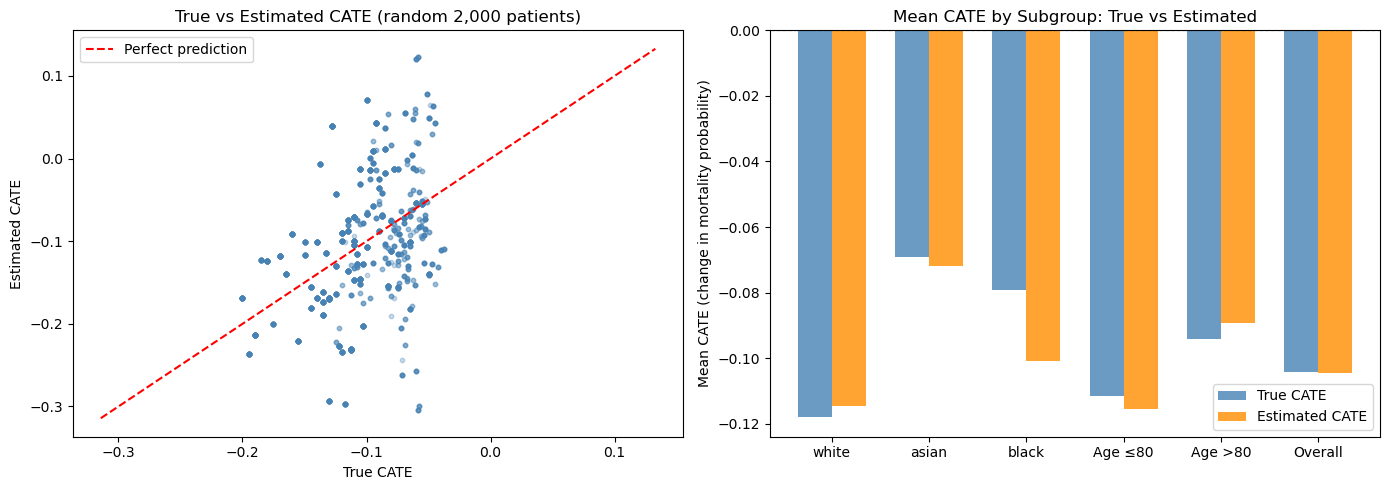

In [9]:
# ─── Encode ethnicity as dummy variables ───
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['ethnicity'], drop_first=False)

feature_cols = ['age', 'male',
                'ethnicity_asian', 'ethnicity_black', 'ethnicity_white']

X = df_model[feature_cols].values.astype(float)
T = df_model['thrombolysis'].values.astype(float)
Y = df_model['died'].values.astype(float)

# ─── Fit Causal Forest ───

cf = CausalForestDML(
    model_y=GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42),
    model_t=GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    discrete_treatment=True,   # T is binary → use classifier for propensity
    discrete_outcome=True,    # ← must be False if using Regressor due to EconML bug
    # n_estimators=500,
    min_samples_leaf=25,
    random_state=42,
)

cf.fit(Y, T, X=X)

# ── Estimate CATE ──
estimated_cate = cf.effect(X).flatten()
df['estimated_cate'] = estimated_cate

# ── Summary by subgroup ───
print("=== Average CATE by Subgroup ===\n")

# By ethnicity
for eth in ['white', 'asian', 'black']:
    mask = df['ethnicity'] == eth
    print(f"Ethnicity={eth:5s}  True CATE: {df.loc[mask,'true_cate'].mean():+.4f}  "
          f"Estimated CATE: {df.loc[mask,'estimated_cate'].mean():+.4f}")

# By age group
for label, mask in [('Age 60-80', df['age'] <= 80), ('Age >80',  df['age'] > 80)]:
    print(f"{label:10s}  True CATE: {df.loc[mask,'true_cate'].mean():+.4f}  "
          f"Estimated CATE: {df.loc[mask,'estimated_cate'].mean():+.4f}")

print(f"\nOverall ATE  True CATE: {df['true_cate'].mean():+.4f}  "
      f"Estimated CATE: {df['estimated_cate'].mean():+.4f}")

# ── Scatter: true vs estimated CATE (sample 2000 pts for clarity) ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter true vs estimated
sample = df.sample(2000, random_state=42)
axes[0].scatter(sample['true_cate'], sample['estimated_cate'],
                alpha=0.3, s=10, color='steelblue')
lims = [min(df['true_cate'].min(), df['estimated_cate'].min()) - 0.01,
        max(df['true_cate'].max(), df['estimated_cate'].max()) + 0.01]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('True CATE')
axes[0].set_ylabel('Estimated CATE')
axes[0].set_title('True vs Estimated CATE (random 2,000 patients)')
axes[0].legend()

# Right: mean CATE by subgroup comparison
subgroups = ['white', 'asian', 'black', 'Age ≤80', 'Age >80', 'Overall']
masks = [
    df['ethnicity'] == 'white',
    df['ethnicity'] == 'asian',
    df['ethnicity'] == 'black',
    df['age'] <= 80,
    df['age'] > 80,
    pd.Series([True] * len(df))
]
true_means = [df.loc[m, 'true_cate'].mean() for m in masks]
est_means  = [df.loc[m, 'estimated_cate'].mean() for m in masks]

x = np.arange(len(subgroups))
w = 0.35
axes[1].bar(x - w/2, true_means, w, label='True CATE', color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, est_means,  w, label='Estimated CATE', color='darkorange', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xticks(x)
axes[1].set_xticklabels(subgroups)
axes[1].set_ylabel('Mean CATE (change in mortality probability)')
axes[1].set_title('Mean CATE by Subgroup: True vs Estimated')
axes[1].legend()

plt.tight_layout()
plt.show()